In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [12]:
df = pd.read_csv("Tehsil_Rainfall_2005_2020.csv")
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date")
df.head()

,system:index,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,...,lang2,lang3,mean,month,rainfall_mm,region_type,valid_on,year,.geo,date
0,0_00000000000000000000,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,23.821348,1.0,23.821348,Tehsil,1662706800000,2005.0,"{""type"":""Polygon"",""coordinates"":[[[73.77759720...",2005-01-01
1,0_00000000000000000001,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,28.990121,1.0,28.990121,Tehsil,1662706800000,2005.0,"{""type"":""Polygon"",""coordinates"":[[[74.13133321...",2005-01-01
2,0_00000000000000000002,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,23.066407,1.0,23.066407,Tehsil,1662706800000,2005.0,"{""type"":""Polygon"",""coordinates"":[[[73.65624272...",2005-01-01
3,0_00000000000000000003,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,40.269855,1.0,40.269855,Tehsil,1662706800000,2005.0,"{""type"":""Polygon"",""coordinates"":[[[74.27960280...",2005-01-01
4,0_00000000000000000004,Pakistan,NaN,NaN,NaN,PK,Punjab,NaN,NaN,NaN,...,NaN,NaN,33.647304,1.0,33.647304,Tehsil,1662706800000,2005.0,"{""type"":""Polygon"",""coordinates"":[[[74.00348633...",2005-01-01


In [13]:
def train_tehsil_model(tehsil_name):
    data = df[df["adm3_name"] == tehsil_name].copy()
    data = data.set_index("date")
    ts = data["rainfall_mm"]
    split = int(len(ts) * 0.7)
    train = ts[:split]
    test = ts[split:]
    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit()
    forecast = results.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"{tehsil_name} RMSE:", rmse)

    plt.figure(figsize=(10,5))
    plt.plot(train, label="Train")
    plt.plot(test, label="Actual")
    plt.plot(forecast, label="Predicted")
    plt.title(f"Rainfall Pattern — {tehsil_name}")
    plt.legend()
    plt.show()

    return results


Training model for: Chunian


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Chunian RMSE: 28.39864815925968


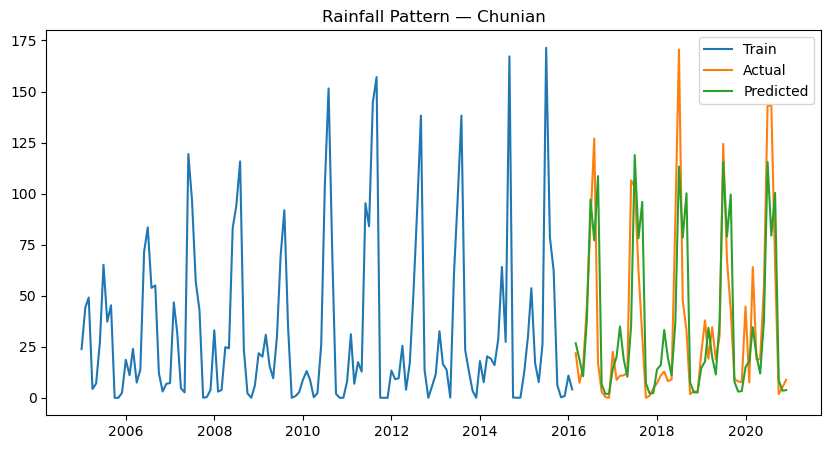


Training model for: Kasur


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Kasur RMSE: 30.245965538587757


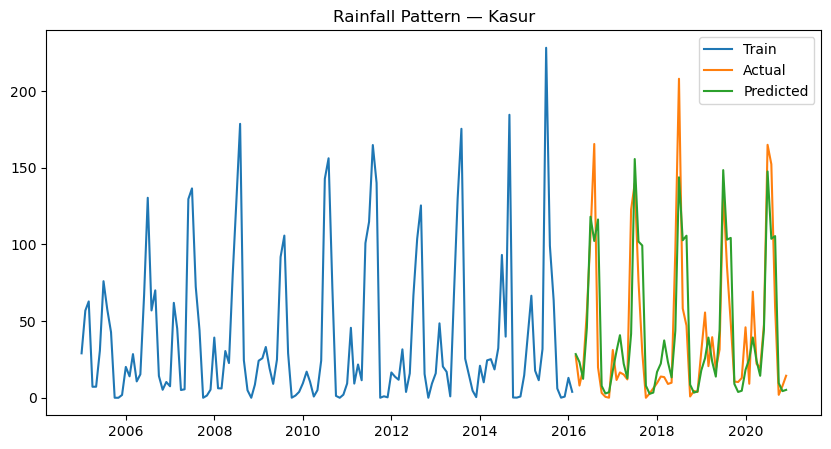


Training model for: Pattoki


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Pattoki RMSE: 30.729715069379537


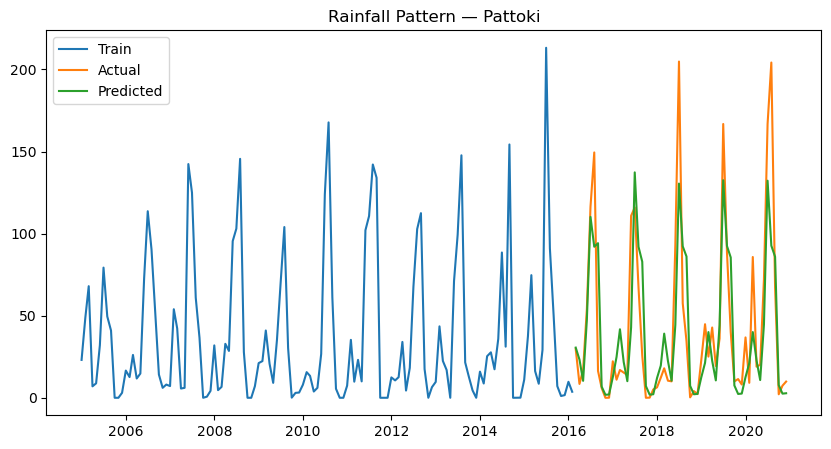


Training model for: Lahore Cantt


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Lahore Cantt RMSE: 48.53425466199897


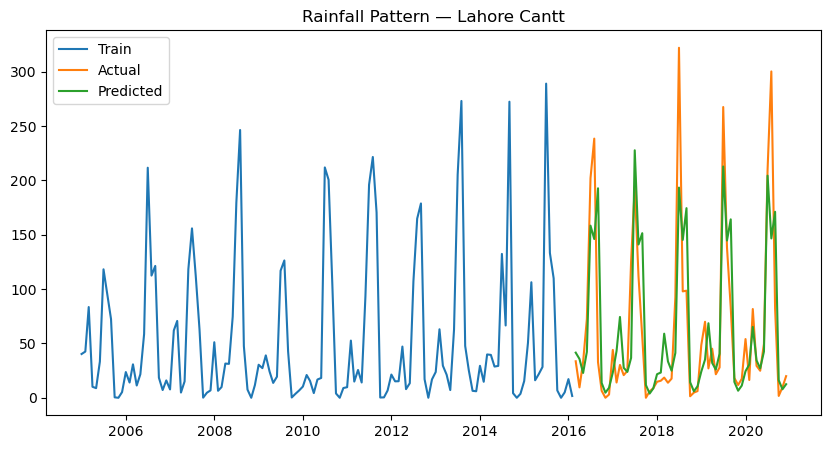


Training model for: Lahore City


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Lahore City RMSE: 41.86801879442929


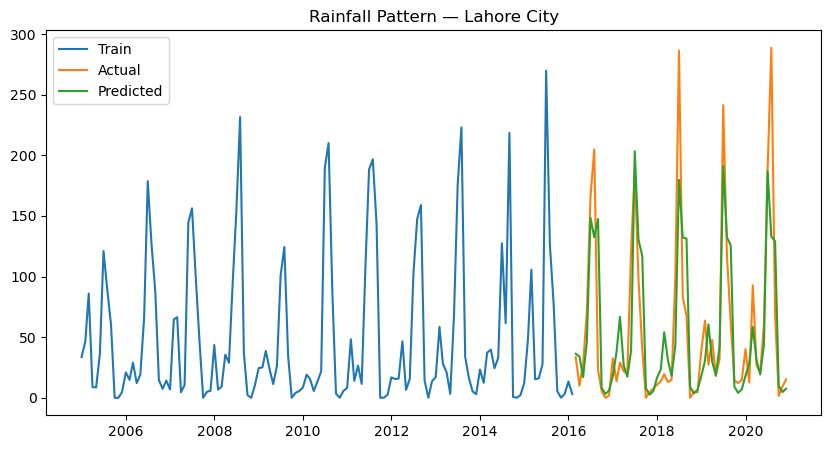


Training model for: Nankana Sahib


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Nankana Sahib RMSE: 30.181751428402162


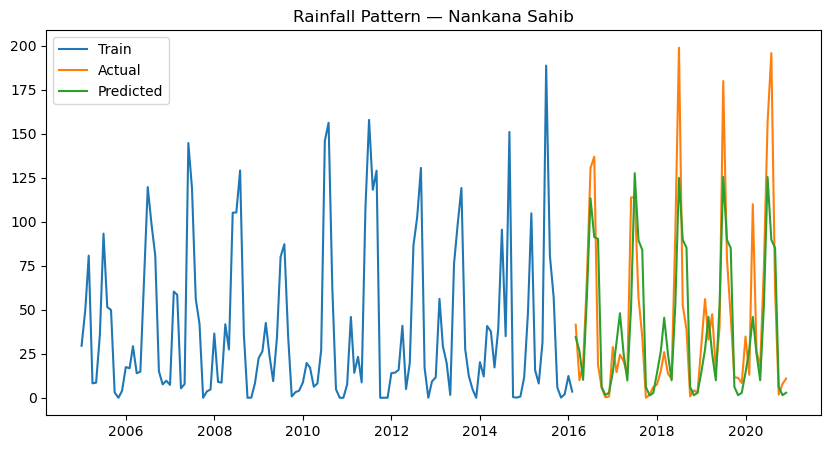


Training model for: Sangla Hill


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Sangla Hill RMSE: 22.75110924643604


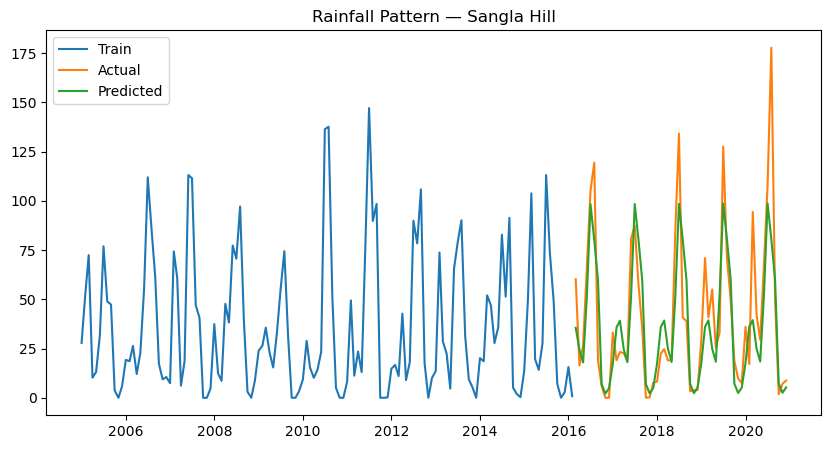


Training model for: Ferozewala


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Ferozewala RMSE: 39.36766927459516


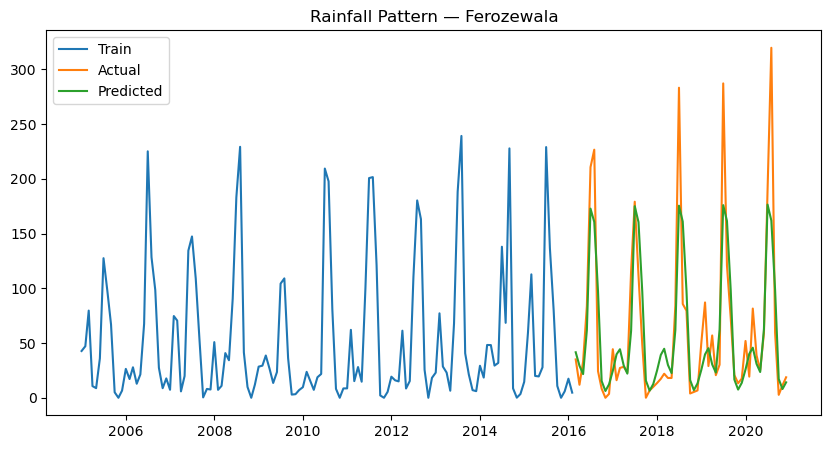


Training model for: Muridke


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Muridke RMSE: 49.27652043138054


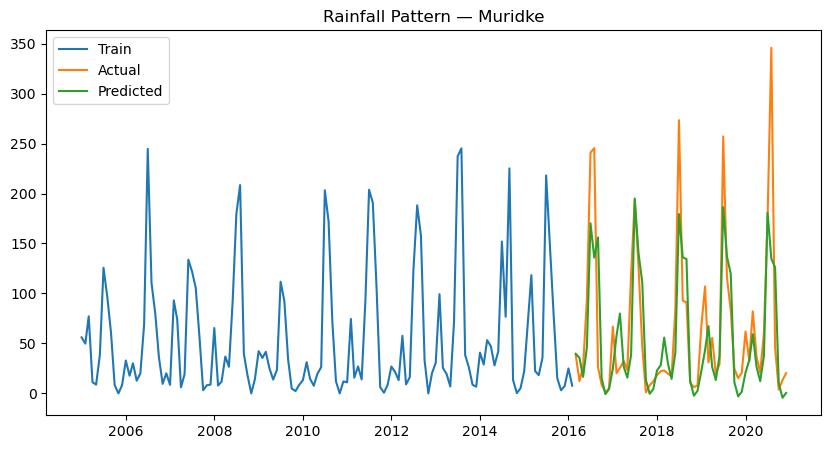


Training model for: Safdarabad


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Safdarabad RMSE: 25.377351341622816


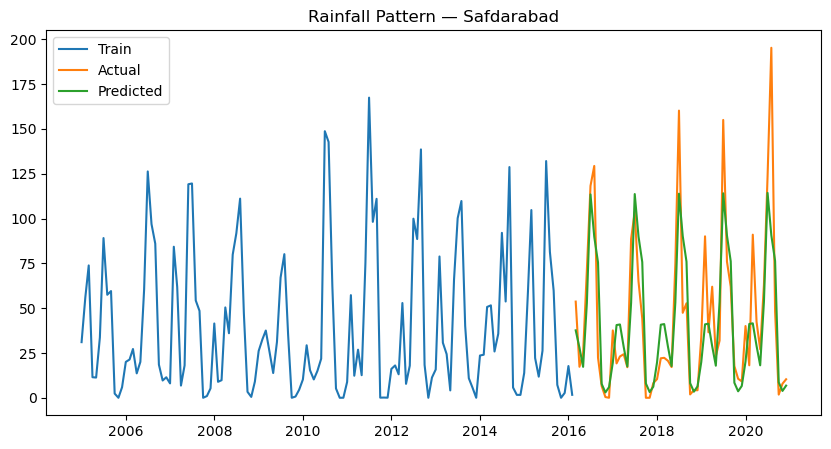


Training model for: Sheikhupura


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Sheikhupura RMSE: 34.28756132846252


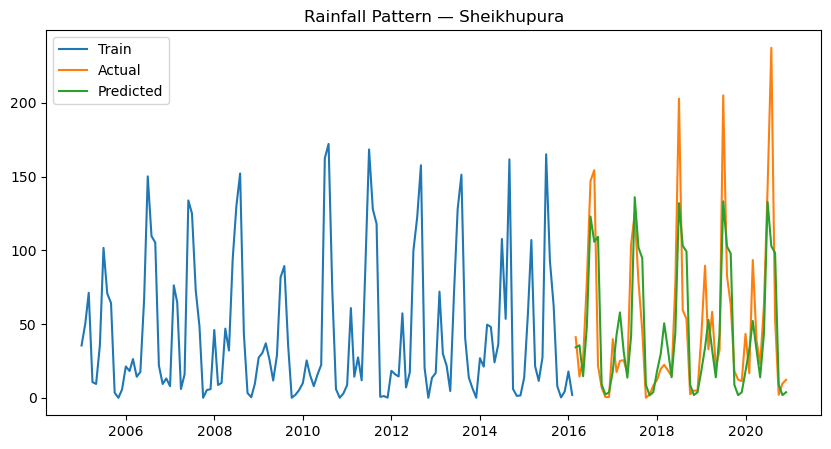

In [14]:
tehsils = df["adm3_name"].unique()

models = {}

for t in tehsils:
    print("\nTraining model for:", t)
    models[t] = train_tehsil_model(t)

In [15]:
tehsil_df = pd.read_csv("Tehsil_Rainfall_2005_2020.csv")
tehsil_df.columns = tehsil_df.columns.str.strip().str.lower().str.replace(" ", "_")
tehsil_df['adm3_name'] = tehsil_df['adm3_name'].str.strip()

In [16]:
# Tehsil-wise monthly average (1995–2025)
tehsil_month_avg = (
    tehsil_df
    .groupby(['adm3_name', 'month'], as_index=False)['rainfall_mm']
    .mean()
)

# Pivot table for heatmap
tehsil_pivot = tehsil_month_avg.pivot(index='adm3_name', columns='month', values='rainfall_mm')


In [17]:
tehsil_total = (
    tehsil_df
    .groupby("adm3_name", as_index=False)["rainfall_mm"]
    .sum()
    .sort_values("rainfall_mm", ascending=False)
)


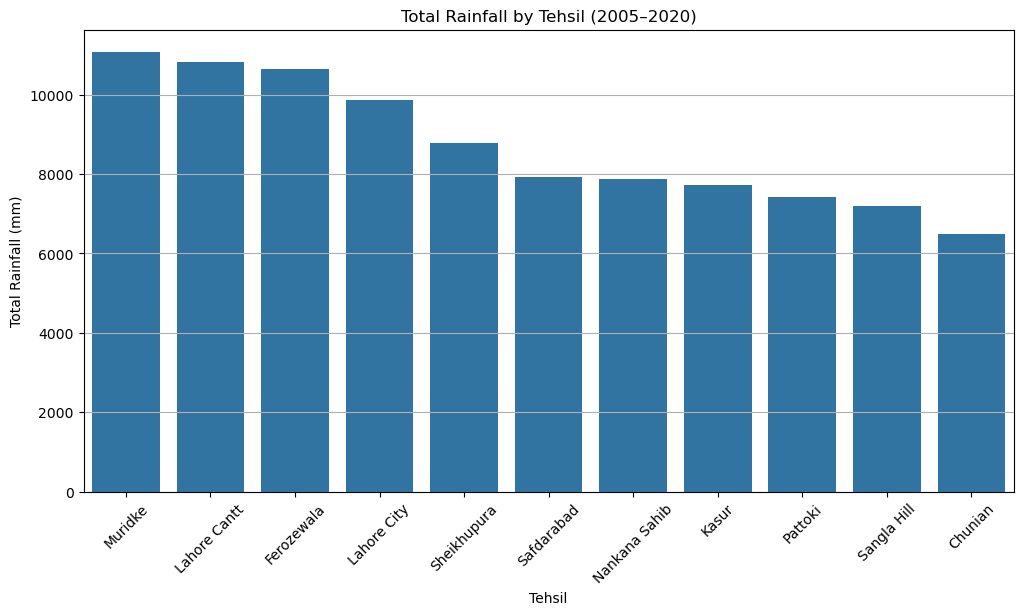

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=tehsil_total,
    x="adm3_name",
    y="rainfall_mm"
)

plt.title("Total Rainfall by Tehsil (2005–2020)")
plt.xlabel("Tehsil")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.savefig("tehsil_total_rainfall_16years.png", dpi=300, bbox_inches="tight")
plt.show()


In [19]:

chunian_data = df[df["adm3_name"] == "Chunian"].copy()
chunian_data = chunian_data.set_index("date")
ts = chunian_data["rainfall_mm"]
overall_mean = ts.mean()
rmse = 28

nrmse = (rmse / overall_mean) * 100

print("Overall Mean Rainfall:", overall_mean)
print("NRMSE %:", nrmse)

Overall Mean Rainfall: 33.81230210264929
NRMSE %: 82.81009649977699


In [23]:
chunian_data = df[df["adm3_name"] == "Chunian"].copy()
chunian_data = chunian_data.set_index("date")
ts = chunian_data["rainfall_mm"]

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = ts["2005-01-01":"2020-12-01"]

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [25]:
import pickle

with open("sarima_model.pkl", "wb") as f:
    pickle.dump(results, f)

In [26]:
data = df[df["adm3_name"] == "Chunian"].copy()
data = data.set_index("date")
ts = data["rainfall_mm"]

train = ts["2005-01-01":"2020-12-01"]

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
